# Experiment 1B: CCISI — Hidden-Layer Perturbation (Learnable Tau + Delay)

## Overview

This notebook implements Experiment 1B from the "Beyond Beyond Rate" project.
We train an SNN (with **learnable tau** AND **learnable axonal delays**) on the
CCISI synthetic task with **no perturbation** (f=0), then evaluate by applying
spike-timing perturbation at the **output of the 1st hidden layer** instead of
the input.

**CCISI task:** Each sample contains 20 neurons arranged in 10 correlated pairs.
Within each pair, neuron A fires first and neuron B follows with a fixed ISI delay.
The class label is determined jointly by firing rate AND cross-channel ISI,
making this a richer temporal coding task than single-channel ISI.

**Key idea:** At test time we intercept the hidden layer's spike output,
replace a fraction *f* of spikes with randomly timed spikes (preserving spike
count per neuron), and measure how downstream accuracy degrades.

| Property | Value |
|---|---|
| Architecture | Input (20) → Hidden (100, SRMALPHA, learnable tau + delay) → Output (2) |
| Delays | Learnable axonal delays on both layers (max 10 time steps) |
| Training | f = 0 (unperturbed inputs) |
| Test-time perturbation | Hidden-layer output, f in {0, 0.2, 0.4, 0.6, 0.8, 1.0} |
| Dataset | CCISI synthetic (`ccisi.h5`), T=1000 time steps |
| Framework | SLAYER (slayerPytorch) |

**Interpretation:**
- Accuracy degrades with increasing f → hidden layer preserves cross-channel temporal structure.
- Accuracy stays flat → hidden layer collapsed cross-channel timing to a rate code.
- Compare with `ccisi_tau.ipynb` to see if delays enable richer internal temporal coding.

## 1. Imports and Setup

In [1]:
import os
import sys
import json
import random
from typing import Optional

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import h5py

# Add SLAYER to path (two levels up from this notebook's directory)
CURRENT_DIR = os.getcwd()
sys.path.append(os.path.join(CURRENT_DIR, "../../src"))
import slayerSNN as snn

MS = 1e-3  # Millisecond constant: 1 ms = 1e-3 s

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## 2. SLAYER and Training Parameters

SLAYER requires neuron and simulation descriptors.
- `tSample = 1000`: 1000 ms (1 s) total sample window.
- `Ts = 0.5`: **0.5 ms sampling resolution (2000 Hz sampling rate)**.
- Dataset spike trains are 2000 time steps long (2000 × 0.5 ms = 1000 ms).
- `SRMALPHA` neurons: spike-response model with alpha-function PSP kernel.
- `MAX_DELAY = 10`: maximum learnable axonal delay in milliseconds,
  matching the 1000-rate baseline's 10 ms delay budget.

In [2]:
# --- SLAYER neuron and simulation descriptors ---
SIM_PARAMS = {"Ts": 0.5, "tSample": 1000}  # 0.5 ms / step, 1000 ms window (2000 Hz)
LIF_PARAMS = {
    "type": "SRMALPHA",
    "theta": 1,
    "tauSr": 1,
    "tauRho": 1,
    "tauRef": 1,
    "scaleRef": 2,
    "scaleRho": 1,
}

# --- Data split ratios ---
TRAIN_RANGE = (0.0, 0.6)
VAL_RANGE   = (0.6, 0.75)
TEST_RANGE  = (0.75, 0.9)

# --- Training hyper-parameters ---
HIDDEN_UNITS  = 100
EPOCHS        = 301
BATCH_SIZE    = 32
LEARNING_RATE = 0.001
SEED          = 48
MAX_DELAY     = 10  # Maximum learnable delay in milliseconds (SLAYER stores delay in ms)

# --- Hidden-perturbation sweep ---
# f=0: no perturbation (baseline); f=1: all temporal structure destroyed
F_VALUES = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
NUM_REPEATS = 3  # Repeated evaluations per f to estimate variance

## 3. Load CCISI Dataset

The CCISI dataset encodes two-class information using cross-channel inter-spike intervals.
Each sample has shape `(num_neurons, T)` with binary spike values.

**Data structure:**
- 20 neurons arranged in 10 pairs (neuron 0/1, 2/3, ..., 18/19).
- Within each pair, neuron A leads; neuron B follows at a fixed ISI.
- Class label reflects the joint (firing_rate, ISI) region in 2D feature space.

In [3]:
def load_ccisi_data(data_file: str = "ccisi.h5"):
    """Load CCISI dataset from HDF5 file.

    Args:
        data_file: Path to the HDF5 file.

    Returns:
        Tuple of (X, Y, firing_rates, isis) arrays.
        X: (N, num_neurons, T) binary spike trains.
        Y: (N,) integer class labels.
        firing_rates: (N,) firing rate feature per sample (Hz).
        isis: (N,) inter-spike-interval feature per sample (ms).
    """
    with h5py.File(data_file, "r") as f:
        X            = f["X"][:]
        Y            = f["Y"][:].ravel()
        firing_rates = f["firing_rates"][:] if "firing_rates" in f else None
        isis         = f["isis"][:]          if "isis"          in f else None

    print(f"Loaded {data_file}: X={X.shape}, Y={Y.shape}")
    print(f"Classes: {np.unique(Y)}, Time steps: {X.shape[2]}")
    if firing_rates is not None:
        print(f"Firing rate range: [{firing_rates.min():.2f}, {firing_rates.max():.2f}] Hz")
    if isis is not None:
        print(f"ISI range: [{isis.min():.1f}, {isis.max():.1f}] ms")
    return X, Y, firing_rates, isis


X_all, Y_all, firing_rates_all, isis_all = load_ccisi_data("ccisi_dataset.h5")
NUM_NEURONS = X_all.shape[1]         # 20 neurons (10 correlated pairs)
NUM_CLASSES = len(np.unique(Y_all))  # 2
print(f"\nNetwork config: {NUM_NEURONS} input neurons, {NUM_CLASSES} classes")

Loaded ccisi_dataset.h5: X=(3598, 20, 2000), Y=(3598,)
Classes: [0 1], Time steps: 2000
Firing rate range: [2.00, 10.00] Hz
ISI range: [1.0, 50.0] ms

Network config: 20 input neurons, 2 classes


### 3a. Dataset Visualisation

Plot the 2D feature space (firing rate vs ISI) to confirm the CCISI structure,
and inspect the ISI distribution per class.

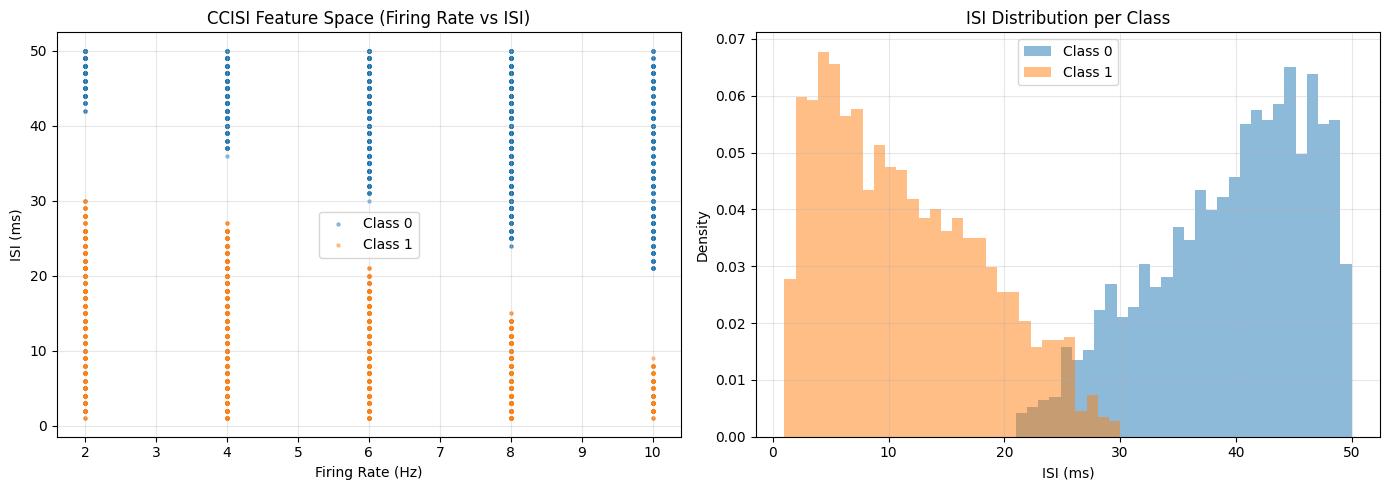

In [4]:
if firing_rates_all is not None and isis_all is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Feature space scatter: firing rate vs ISI, coloured by class
    for cls, color, label in zip([0, 1], ["tab:blue", "tab:orange"], ["Class 0", "Class 1"]):
        mask = Y_all == cls
        axes[0].scatter(
            firing_rates_all[mask], isis_all[mask],
            s=5, alpha=0.4, color=color, label=label,
        )
    axes[0].set_xlabel("Firing Rate (Hz)")
    axes[0].set_ylabel("ISI (ms)")
    axes[0].set_title("CCISI Feature Space (Firing Rate vs ISI)")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # ISI histogram per class to show temporal feature separation
    for cls, color, label in zip([0, 1], ["tab:blue", "tab:orange"], ["Class 0", "Class 1"]):
        mask = Y_all == cls
        axes[1].hist(isis_all[mask], bins=30, alpha=0.5, color=color, label=label, density=True)
    axes[1].set_xlabel("ISI (ms)")
    axes[1].set_ylabel("Density")
    axes[1].set_title("ISI Distribution per Class")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## 4. Hidden-Layer Spike Perturbation

The core perturbation mechanism from "Beyond Beyond Rate".
Given a hidden layer's binary spike output of shape `(neurons, T)`, we:
1. For each neuron, randomly select a fraction `f` of its spikes.
2. Remove them from their original positions.
3. Place the same number of spikes at uniformly random (previously-silent) time bins.

This destroys the temporal structure (including cross-channel ISI relationships
between hidden neurons) while **preserving each neuron's total spike count**.
Therefore, any accuracy drop under this perturbation reveals that the hidden
layer was encoding information temporally — not just in firing rates.

In [5]:
def partial_randomize_spike_train(
    spike_train: np.ndarray,
    f: float = 0.0,
    max_attempts: int = 50,
) -> np.ndarray:
    """Randomly relocate a fraction *f* of each neuron's spikes (numpy ref impl).

    Kept for documentation / numpy-only callers. The training and evaluation
    paths use the vectorised GPU version ``perturb_hidden_batch`` below.

    SLAYER outputs 1/Ts per spike (e.g. 2.0 at Ts=0.5), so we detect spikes
    with a > 0.5 threshold and re-write relocated spikes with the same
    magnitude rather than hard-coding 1.

    Args:
        spike_train: Array of shape (num_neurons, T). Non-spike bins are 0;
            spike bins hold the SLAYER spike magnitude (1/Ts).
        f: Fraction of spikes to relocate (0 = untouched, 1 = fully random).
        max_attempts: Max placement retries per spike.

    Returns:
        Perturbed spike train with the same shape and magnitude.
    """
    if f <= 0:
        return spike_train

    num_neurons, T = spike_train.shape
    new_train = np.copy(spike_train)

    for neuron_idx in range(num_neurons):
        spike_times = np.where(spike_train[neuron_idx] > 0.5)[0]
        if len(spike_times) == 0:
            continue
        spike_value = float(spike_train[neuron_idx, spike_times[0]])

        num_to_move = int(len(spike_times) * f)
        if num_to_move == 0:
            continue

        chosen = np.random.choice(spike_times, size=num_to_move, replace=False)
        new_train[neuron_idx, chosen] = 0

        placed = 0
        for _ in range(max_attempts * num_to_move):
            if placed >= num_to_move:
                break
            new_t = np.random.randint(0, T)
            if new_train[neuron_idx, new_t] < 0.5:
                new_train[neuron_idx, new_t] = spike_value
                placed += 1

    return new_train


@torch.no_grad()
def perturb_hidden_batch(
    hidden_spikes: torch.Tensor,
    f: float = 0.0,
) -> torch.Tensor:
    """Vectorised GPU-side partial spike relocation.

    For each (batch, neuron), a fraction *f* of the existing spikes are
    removed and replaced with the same number of spikes placed at randomly
    chosen previously-unoccupied time bins. Spike count per neuron is
    preserved exactly, and the original spike magnitude (SLAYER outputs
    1/Ts per spike, so 2.0 at Ts=0.5) is preserved on the relocated
    spikes. All operations stay on the input tensor's device.

    Args:
        hidden_spikes: SLAYER-format tensor of shape (B, C, 1, 1, T).
        f: Fraction of spikes to relocate (0 = untouched, 1 = fully random).

    Returns:
        Perturbed tensor with the same shape, dtype, and device.
    """
    if f <= 0:
        return hidden_spikes

    B, C, H, W, T = hidden_spikes.shape
    x = hidden_spikes.view(B, C, T)
    is_spike = x > 0.5
    if not is_spike.any():
        return hidden_spikes

    # Detect SLAYER's spike magnitude (1/Ts) from the data itself, so the
    # function stays independent of SIM_PARAMS and matches whatever the
    # network is actually producing.
    spike_value = x[is_spike].max().item()

    n_spikes = is_spike.sum(dim=-1, keepdim=True)            # (B, C, 1)
    num_to_move = (n_spikes.float() * f).floor().long()       # (B, C, 1)

    # --- 1. Choose which existing spikes to remove ---
    # Random key per time bin; non-spike bins get +inf so they sort last.
    key = torch.rand_like(x)
    key = torch.where(is_spike, key, torch.full_like(key, 2.0))
    rank = key.argsort(dim=-1).argsort(dim=-1)
    remove_mask = rank < num_to_move                          # (B, C, T)
    keep_mask = is_spike & ~remove_mask

    # --- 2. Place the same number of spikes in currently-unoccupied bins ---
    available = ~keep_mask
    key2 = torch.rand_like(x)
    key2 = torch.where(available, key2, torch.full_like(key2, 2.0))
    rank2 = key2.argsort(dim=-1).argsort(dim=-1)
    add_mask = rank2 < num_to_move

    # Re-emit spikes at the original SLAYER magnitude (not 0/1).
    new_spikes = (keep_mask | add_mask).to(hidden_spikes.dtype) * spike_value
    return new_spikes.view(B, C, H, W, T)

## 5. Dataset and Data Splitting

A `Dataset` wrapper and helper to create train / validation / test DataLoaders.
Training always uses **unperturbed** data (f=0); perturbation is applied only
at test time inside the network's forward pass.

In [6]:
class SpikeDataset(Dataset):
    """Wrap numpy spike trains and labels into a PyTorch Dataset."""

    def __init__(self, X: np.ndarray, Y: np.ndarray):
        self.X = X
        self.Y = Y

    def __len__(self) -> int:
        return len(self.Y)

    def __getitem__(self, idx: int):
        x = torch.tensor(self.X[idx], dtype=torch.float32)
        y = torch.tensor(self.Y[idx], dtype=torch.long)
        return x, y


def get_split_indices(split_range: tuple, total: int) -> np.ndarray:
    """Return integer indices for the given fractional range."""
    return np.arange(int(split_range[0] * total), int(split_range[1] * total))


def build_dataloaders(
    X: np.ndarray,
    Y: np.ndarray,
    batch_size: int = 32,
) -> tuple:
    """Split data and return (train, val, test) DataLoaders.

    Data is NOT perturbed here — perturbation happens only at inference time
    inside forward_with_hidden_perturbation.

    Args:
        X: Spike-train array (N, num_neurons, T).
        Y: Label array (N,).
        batch_size: Mini-batch size.

    Returns:
        Tuple of (train_loader, val_loader, test_loader).
    """
    train_idx = get_split_indices(TRAIN_RANGE, len(X))
    val_idx   = get_split_indices(VAL_RANGE,   len(X))
    test_idx  = get_split_indices(TEST_RANGE,  len(X))

    train_ds = SpikeDataset(X[train_idx], Y[train_idx])
    val_ds   = SpikeDataset(X[val_idx],   Y[val_idx])
    test_ds  = SpikeDataset(X[test_idx],  Y[test_idx])

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

    print(f"Split sizes — Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")
    return train_loader, val_loader, test_loader

## 6. Network Architecture

A single-hidden-layer SLAYER SNN with a **learnable PSP filter** AND **learnable
axonal delays** on both layers. This is the SGD-delay variant.

```
Input (20) → [delay1 + psp_filter + fc1 + spike] → Hidden (100)
                                                        ↓
                                     ← perturbation applied here at test time
                                                        ↓
                              [delay2 + psp + fc2 + spike] → Output (2)
```

Two forward methods are provided:
- `forward`: standard pass used during training (no perturbation).
- `forward_with_hidden_perturbation`: intercepts hidden spikes,
  applies perturbation at level *f*, then continues to output.

In [7]:
class CCISIDelayNetwork(nn.Module):
    """SLAYER SNN for CCISI classification with learnable tau AND axonal delays.

    This is the SGD-delay variant. Delay modules are applied on both layers.
    Exposes forward_with_hidden_perturbation for test-time evaluation.
    """

    def __init__(
        self,
        num_neurons: int,
        num_classes: int,
        hidden_units: int = 100,
        max_delay: int = 10,
    ):
        super().__init__()
        self.max_delay = max_delay
        slayer = snn.layer(LIF_PARAMS, SIM_PARAMS)
        self.slayer = slayer

        # Two fully-connected SLAYER layers with weight normalisation
        self.fc1 = nn.utils.weight_norm(
            slayer.dense(num_neurons, hidden_units), name="weight"
        )
        self.fc2 = nn.utils.weight_norm(
            slayer.dense(hidden_units, num_classes), name="weight"
        )

        # Learnable PSP filter — replaces the fixed-tau PSP for the first layer.
        # filterLength=100 taps at Ts=0.5 ms covers 50 ms of history,
        # matching the 1000-rate baseline's 50-tap / 50 ms filter.
        self.psp_filter = slayer.pspFilter(nFilter=1, filterLength=100, filterScale=1)
        self._initialize_alpha_filter()

        # Learnable axonal delay modules on both layers
        self.delay1 = slayer.delay(num_neurons)
        self.delay2 = slayer.delay(hidden_units)
        self._initialize_delays()

    # ------------------------------------------------------------------
    # Initialisation helpers
    # ------------------------------------------------------------------

    def _initialize_alpha_filter(self) -> None:
        """Seed the learnable PSP filter with an alpha-function shape.

        Alpha function: t/tau * exp(1 - t/tau). Provides a biologically
        plausible starting point; tau then adapts during training.
        """
        tau      = 50 * MS
        Ts       = self.slayer.simulation["Ts"] * MS
        filt_len = self.psp_filter.weight.shape[-1]

        alpha_kernel = np.array([
            t / tau * np.exp(1 - t / tau)
            for t in np.arange(0, filt_len * Ts, Ts)
        ])
        if np.max(np.abs(alpha_kernel)) > 0:
            alpha_kernel /= np.max(np.abs(alpha_kernel))

        # SLAYER uses a time-reversed (flipped) kernel for causal convolution
        with torch.no_grad():
            self.psp_filter.weight.data = torch.FloatTensor(
                np.flip(alpha_kernel).copy()
            ).reshape(self.psp_filter.weight.shape)

    def _initialize_delays(self) -> None:
        """Initialize delay parameters uniformly in [0, max_delay]."""
        with torch.no_grad():
            if hasattr(self.delay1, "delay"):
                self.delay1.delay.data.uniform_(0, self.max_delay)
            if hasattr(self.delay2, "delay"):
                self.delay2.delay.data.uniform_(0, self.max_delay)

    def get_tau(self) -> torch.Tensor:
        """Estimate the effective tau (s) from the peak of the learned PSP filter."""
        weights = self.psp_filter.weight.data.squeeze().cpu().numpy()
        weights = np.flip(weights)  # Unflip to get actual temporal response
        if len(weights) > 0:
            peak_idx      = np.argmax(np.abs(weights))
            estimated_tau = 3 * peak_idx * self.slayer.simulation["Ts"] * MS
            return torch.tensor(max(estimated_tau, 10 * MS))
        return torch.tensor(50 * MS)

    def get_delays(self) -> dict:
        """Get current delay values as numpy arrays.

        Returns:
            Dict with keys 'delay1' and 'delay2', each a numpy array.
        """
        delays = {}
        if hasattr(self.delay1, "delay"):
            delays["delay1"] = self.delay1.delay.data.cpu().numpy()
        if hasattr(self.delay2, "delay"):
            delays["delay2"] = self.delay2.delay.data.cpu().numpy()
        return delays

    # ------------------------------------------------------------------
    # Internal layer helpers
    # ------------------------------------------------------------------

    def _prepare_input(self, x: torch.Tensor) -> torch.Tensor:
        """Ensure input is 5-D SLAYER format (N, C, 1, 1, T) on the correct device."""
        if isinstance(x, np.ndarray):
            x = torch.from_numpy(x)
        if x.dim() == 3:  # (N, neurons, T) -> (N, neurons, 1, 1, T)
            x = x.unsqueeze(2).unsqueeze(3)
        # Scale binary inputs to SLAYER's 1/Ts spike-magnitude convention so
        # the first-layer PSP integral is Ts-invariant (matches what
        # `slayer.spike` emits internally).
        return x.float().to(device) / self.slayer.simulation['Ts']

    def _first_layer(self, x: torch.Tensor) -> torch.Tensor:
        """Input -> hidden spikes through delay1 + learnable PSP filter + fc1."""
        x = self.delay1(x)
        x_filtered = self.psp_filter(x)
        return self.slayer.spike(self.fc1(x_filtered))

    def _second_layer(self, hidden_spikes: torch.Tensor) -> torch.Tensor:
        """Hidden spikes -> output spikes through delay2 + standard PSP + fc2."""
        x = self.delay2(hidden_spikes)
        return self.slayer.spike(self.fc2(self.slayer.psp(x)))

    # ------------------------------------------------------------------
    # Forward passes
    # ------------------------------------------------------------------

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Standard forward pass — no perturbation. Used during training."""
        x = self._prepare_input(x)
        hidden_spikes = self._first_layer(x)
        return self._second_layer(hidden_spikes)

    def forward_with_hidden_perturbation(
        self,
        x: torch.Tensor,
        f: float = 0.0,
    ) -> torch.Tensor:
        """Forward pass with perturbation at the hidden-layer spike output.

        Performs the first layer normally, then disrupts the temporal
        structure of the hidden spike train before passing to layer 2.

        Args:
            x: Input spike trains.
            f: Fraction of hidden spikes to randomly relocate (0=none, 1=all).

        Returns:
            Output spike tensor after perturbed hidden representation.
        """
        x = self._prepare_input(x)
        hidden_spikes = self._first_layer(x)

        # --- Perturbation hook ---
        # Temporal structure is selectively destroyed here.
        # Spike counts (and thus rate codes) are preserved.
        if f > 0:
            hidden_spikes = perturb_hidden_batch(hidden_spikes, f)

        return self._second_layer(hidden_spikes)

## 7. Training Loop

Train the `CCISIDelayNetwork` on **unperturbed** data (f=0). Key design choices:
- **SLAYER ProbSpikes loss**: surrogate-gradient loss for SNNs.
- **Nadam optimiser** with separate learning rates:
  - Regular parameters: base LR.
  - PSP filter (tau): LR × 10 for faster temporal adaptation.
  - Delay parameters: LR × 5 for stable delay learning.
- **MultiStepLR scheduler**: halves the LR at epoch 300.
- **Best-model checkpointing** based on validation loss.

In [8]:
def train_model(
    train_loader: DataLoader,
    val_loader: DataLoader,
    num_neurons: int,
    num_classes: int,
    hidden_units: int = 100,
    max_delay: int = 10,
    epochs: int = 301,
    lr: float = 0.001,
    seed: int = 42,
) -> tuple:
    """Train the CCISIDelayNetwork on unperturbed data.

    Args:
        train_loader: Training DataLoader.
        val_loader: Validation DataLoader.
        num_neurons: Number of input neurons.
        num_classes: Number of output classes.
        hidden_units: Hidden layer size.
        max_delay: Maximum learnable delay in milliseconds.
        epochs: Number of training epochs.
        lr: Base learning rate.
        seed: Random seed for reproducibility.

    Returns:
        Tuple of (trained CCISIDelayNetwork, training log dict).
    """
    # Reproducibility
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    net = CCISIDelayNetwork(num_neurons, num_classes, hidden_units, max_delay).to(device)

    # SLAYER ProbSpikes loss
    loss_fn = snn.spikeLoss.spikeLoss({
        "neuron":     LIF_PARAMS,
        "simulation": SIM_PARAMS,
        "training":   {"error": {"type": "ProbSpikes"}},
    }).to(device)

    # Separate parameter groups: regular, PSP filter (tau), delay
    psp_params   = list(net.psp_filter.parameters())
    delay_params = []
    for name, param in net.named_parameters():
        if "delay" in name:
            delay_params.append(param)

    psp_ids   = {id(p) for p in psp_params}
    delay_ids = {id(p) for p in delay_params}
    other_params = [
        p for p in net.parameters()
        if id(p) not in psp_ids and id(p) not in delay_ids
    ]

    optimizer = snn.utils.optim.Nadam([
        {"params": other_params, "lr": lr},
        {"params": psp_params,   "lr": lr * 10},  # Faster tau adaptation
        {"params": delay_params, "lr": lr * 5},    # Moderate delay learning
    ])
    scheduler = torch.optim.lr_scheduler.MultiStepLR(
        optimizer, milestones=[300], gamma=0.5
    )

    best_val_loss    = float("inf")
    best_model_state = None
    tau_history: list = []
    delay_history: list = []

    log = {
        "epoch": [], "train_loss": [], "val_loss": [],
        "tau": [], "delay_mean": [],
    }

    total_steps = epochs * len(train_loader)
    with tqdm(total=total_steps, desc="Training") as pbar:
        for epoch in range(epochs):

            # --- Training phase ---
            net.train()
            epoch_loss  = 0.0
            batch_count = 0

            for x_batch, y_batch in train_loader:
                if x_batch.dim() == 3:
                    x_batch = x_batch.unsqueeze(2).unsqueeze(3)
                x_batch = x_batch.to(device).float()
                y_batch = y_batch.to(device)

                outputs     = net(x_batch)
                loss        = loss_fn.probSpikes(outputs, y_batch)
                epoch_loss  += loss.item()
                batch_count += 1

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                pbar.update(1)

            # --- Validation phase ---
            net.eval()
            val_loss = 0.0
            with torch.no_grad():
                for x_batch, y_batch in val_loader:
                    if x_batch.dim() == 3:
                        x_batch = x_batch.unsqueeze(2).unsqueeze(3)
                    x_batch = x_batch.to(device).float()
                    y_batch = y_batch.to(device)

                    outputs   = net(x_batch)
                    val_loss += loss_fn.probSpikes(outputs, y_batch).item()

            val_loss   /= len(val_loader)
            epoch_loss /= batch_count
            tau_val     = net.get_tau().item() / MS
            tau_history.append(tau_val)

            # Record delay statistics
            delays = net.get_delays()
            delay_history.append(delays)
            avg_delay = np.mean([
                np.mean(d) for d in delays.values() if len(d) > 0
            ])

            # Log metrics every epoch
            if epoch % 1 == 0:
                log["epoch"].append(epoch)
                log["train_loss"].append(epoch_loss)
                log["val_loss"].append(val_loss)
                log["tau"].append(tau_val)
                log["delay_mean"].append(float(avg_delay))

            if val_loss < best_val_loss:
                best_val_loss    = val_loss
                best_model_state = {k: v.clone() for k, v in net.state_dict().items()}

            scheduler.step()
            pbar.set_postfix(
                epoch=epoch + 1,
                val_loss=f"{val_loss:.4f}",
                best=f"{best_val_loss:.4f}",
                tau=f"{tau_val:.1f}ms",
                delay=f"{avg_delay:.1f}",
            )

    # Restore the checkpoint with the lowest validation loss
    if best_model_state is not None:
        net.load_state_dict(best_model_state)

    log["tau_history"] = tau_history
    log["delay_history"] = [
        {k: v.tolist() for k, v in d.items()} for d in delay_history
    ]
    return net, log

## 8. Testing with Hidden-Layer Perturbation

Evaluate the trained model by sweeping over perturbation levels `f`.
For each `f`, we use `forward_with_hidden_perturbation` which intercepts
the first hidden layer's spike output before passing it to layer 2.

Each level is repeated `NUM_REPEATS` times with different random seeds to
obtain mean ± std accuracy estimates.

In [9]:
def test_with_hidden_perturbation(
    net: CCISIDelayNetwork,
    test_loader: DataLoader,
    f: float = 0.0,
) -> float:
    """Evaluate accuracy with hidden-layer perturbation at level *f*.

    Args:
        net: Trained CCISIDelayNetwork.
        test_loader: Test DataLoader.
        f: Perturbation fraction applied to hidden spikes.

    Returns:
        Test accuracy as a float in [0, 1].
    """
    net.eval()
    correct = 0
    total   = 0

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            if x_batch.dim() == 3:
                x_batch = x_batch.unsqueeze(2).unsqueeze(3)
            x_batch = x_batch.to(device).float()
            y_batch = y_batch.to(device)

            outputs   = net.forward_with_hidden_perturbation(x_batch, f=f)
            predicted = snn.predict.getClass(outputs)

            total   += y_batch.size(0)
            correct += (predicted.cpu() == y_batch.cpu()).sum().item()

    return correct / total


def run_hidden_perturbation_sweep(
    net: CCISIDelayNetwork,
    test_loader: DataLoader,
    f_values: list,
    num_repeats: int = 3,
) -> dict:
    """Sweep over perturbation levels and collect accuracy statistics.

    Args:
        net: Trained CCISIDelayNetwork.
        test_loader: Test DataLoader.
        f_values: List of perturbation fractions to evaluate.
        num_repeats: Number of independent evaluations per f (different seeds).

    Returns:
        Dict mapping each f to {"mean", "std", "values"}.
    """
    results = {}

    for f in f_values:
        accuracies = []
        for repeat in range(num_repeats):
            np.random.seed(SEED + repeat)
            acc = test_with_hidden_perturbation(net, test_loader, f=f)
            accuracies.append(acc)

        mean_acc = float(np.mean(accuracies))
        std_acc  = float(np.std(accuracies))
        results[f] = {"mean": mean_acc, "std": std_acc, "values": accuracies}
        print(f"  f={f:.1f}:  accuracy = {mean_acc:.4f} +/- {std_acc:.4f}")

    return results

## 9. Visualisation Utilities

Plotting helpers for:
1. Training / validation loss curves, tau evolution, and delay evolution.
2. Accuracy vs hidden-perturbation level *f* (the main result plot).

In [10]:
def plot_training_curves(log: dict) -> None:
    """Plot training/validation loss, tau evolution, and delay evolution."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Loss curves
    axes[0].plot(log["epoch"], log["train_loss"], "o-", label="Train loss", markersize=2)
    axes[0].plot(log["epoch"], log["val_loss"],   "s-", label="Val loss", markersize=2)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("ProbSpikes Loss")
    axes[0].set_title("Training and Validation Loss\n(CCISI, learnable tau + delay)")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Tau evolution
    axes[1].plot(log["tau_history"])
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Effective Tau (ms)")
    axes[1].set_title("Learned Tau Evolution (CCISI)")
    axes[1].grid(True, alpha=0.3)

    # Delay evolution
    axes[2].plot(log["delay_mean"])
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Average Delay (time steps)")
    axes[2].set_title("Average Delay Evolution (CCISI)")
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_hidden_perturbation_curve(
    results: dict,
    save_path: Optional[str] = None,
) -> None:
    """Plot accuracy vs hidden-perturbation level f.

    Args:
        results: Output of run_hidden_perturbation_sweep.
        save_path: If provided, save the figure to this path.
    """
    f_vals = sorted(results.keys())
    means  = [results[f]["mean"] for f in f_vals]
    stds   = [results[f]["std"]  for f in f_vals]
    chance = 1.0 / NUM_CLASSES

    plt.figure(figsize=(8, 5))
    plt.errorbar(
        f_vals, means, yerr=stds,
        fmt="o-", capsize=5, capthick=2,
        color="tab:orange", label="SGD-delay (learnable tau + delay)",
    )
    plt.axhline(
        chance, color="gray", linestyle="--", linewidth=1,
        label=f"Chance level ({chance:.2f})",
    )
    plt.xlabel("Hidden Perturbation Level (f)")
    plt.ylabel("Test Accuracy")
    plt.title(
        "Exp 1B — CCISI: Accuracy vs Hidden-Layer Perturbation\n"
        "(Learnable Tau + Delay)"
    )
    plt.ylim(0, 1.05)
    plt.grid(True, alpha=0.3)
    plt.legend()

    for f_val, mean in zip(f_vals, means):
        plt.annotate(
            f"{mean:.3f}",
            (f_val, mean),
            textcoords="offset points",
            xytext=(0, 12),
            ha="center",
            fontsize=9,
        )

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Figure saved to {save_path}")
    plt.show()

## 10. Run: Train the Model (f=0)

Train on unperturbed CCISI data using the 301-epoch schedule from Beyond Rate.
The best checkpoint (lowest validation loss) is restored and saved to disk.

In [11]:
# Build DataLoaders — no perturbation at training time
train_loader, val_loader, test_loader = build_dataloaders(
    X_all, Y_all, batch_size=BATCH_SIZE
)

# Train
net, training_log = train_model(
    train_loader=train_loader,
    val_loader=val_loader,
    num_neurons=NUM_NEURONS,
    num_classes=NUM_CLASSES,
    hidden_units=HIDDEN_UNITS,
    max_delay=MAX_DELAY,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    seed=SEED,
)

# Sanity check: clean accuracy with no perturbation
clean_acc = test_with_hidden_perturbation(net, test_loader, f=0.0)
print(f"\nClean test accuracy (f=0, no perturbation): {clean_acc:.4f}")

# Save the trained model
os.makedirs("data", exist_ok=True)
model_path = "data/ccisi_delay_trained.pt"
torch.save(net.state_dict(), model_path)
print(f"Model saved to {model_path}")

Split sizes — Train: 2158, Val: 540, Test: 540


d:\IC_2025\IRP\workspace\venv\Lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
Training:   0%|          | 0/20468 [00:00<?, ?it/s]d:\IC_2025\IRP\workspace\venv\Lib\site-packages\slayersnn-0.0.0-py3.11.egg\slayerSNN\optimizer.py:94: UserWarning: This overload of add_ is deprecated:
	add_(Number alpha, Tensor other)
Consider using one of the following signatures instead:
	add_(Tensor other, *, Number alpha = 1) (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\python_arg_parser.cpp:1691.)
  exp_avg.mul_(beta1).add_(1 - beta1, grad)
Training: 100%|██████████| 20468/20468 [22:04<00:00, 15.45it/s, best=0.0668, delay=5.3, epoch=301, tau=85.5ms, val_loss=0.0676]



Clean test accuracy (f=0, no perturbation): 0.9889
Model saved to data/ccisi_delay_trained.pt


## 11. Plot Training Curves

Inspect loss convergence, how the learned tau adapts, and how delay values
evolve during training. A converging tau indicates the network is learning a
stable temporal filter; changing delays show temporal shift learning.

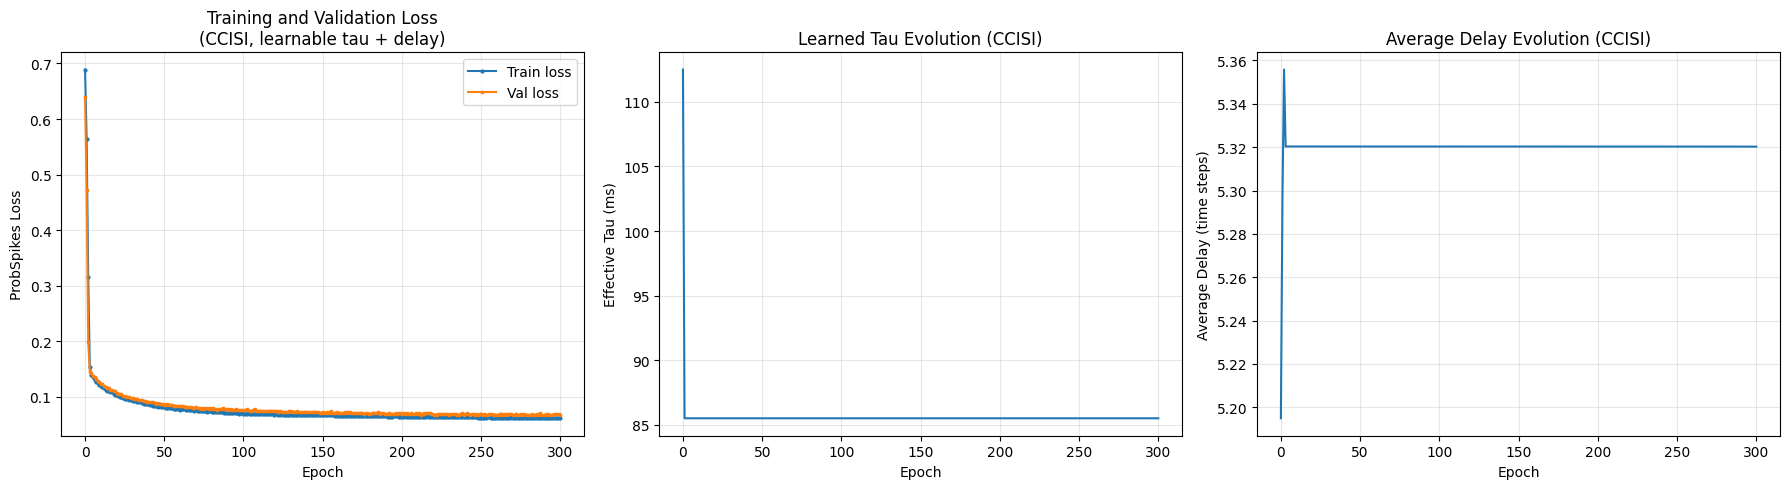

In [12]:
plot_training_curves(training_log)

## 12. Hidden-Perturbation Sweep

Apply perturbation at the hidden-layer output for f in {0, 0.2, 0.4, 0.6, 0.8, 1.0}.
Each level is repeated `NUM_REPEATS` times with different random seeds for error bars.

**What to look for:**
- **Steep degradation with f:** The hidden layer preserves cross-channel temporal
  structure — the representation is spike-timing based even after the first layer.
- **Flat curve near clean accuracy:** The hidden layer collapsed cross-channel
  ISI information into a rate code internally.
- **Compare with `ccisi_tau.ipynb`:** If the delay model degrades more steeply
  than the tau-only model, learnable delays enable richer internal temporal coding.

In [13]:
print("=== Hidden-Layer Perturbation Sweep (CCISI, learnable tau + delay) ===")
sweep_results = run_hidden_perturbation_sweep(
    net, test_loader,
    f_values=F_VALUES,
    num_repeats=NUM_REPEATS,
)

=== Hidden-Layer Perturbation Sweep (CCISI, learnable tau + delay) ===
  f=0.0:  accuracy = 0.9889 +/- 0.0000
  f=0.1:  accuracy = 0.9772 +/- 0.0023
  f=0.2:  accuracy = 0.9765 +/- 0.0063
  f=0.3:  accuracy = 0.9735 +/- 0.0038
  f=0.4:  accuracy = 0.9605 +/- 0.0017
  f=0.5:  accuracy = 0.9389 +/- 0.0066
  f=0.6:  accuracy = 0.8988 +/- 0.0115
  f=0.7:  accuracy = 0.8401 +/- 0.0061
  f=0.8:  accuracy = 0.8117 +/- 0.0148
  f=0.9:  accuracy = 0.7864 +/- 0.0107
  f=1.0:  accuracy = 0.7660 +/- 0.0215


## 13. Plot Hidden-Perturbation Results

Figure saved to log/ccisi_delay_hidden_perturbation.png


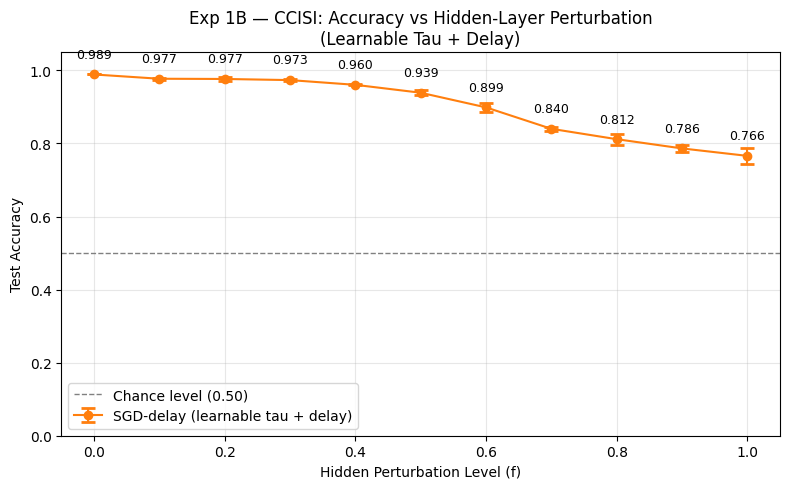

In [14]:
plot_hidden_perturbation_curve(
    sweep_results,
    save_path="log/ccisi_delay_hidden_perturbation.png",
)

## 14. Save Results

Save the perturbation sweep results and training log to JSON for:
- Later side-by-side comparison with `ccisi_tau.ipynb` (SGD tau-only model).
- Comparison against the original input-perturbation baseline from Beyond Rate.

In [15]:
# Save perturbation sweep results
results_serialisable = {
    str(f_val): {
        "mean":   float(data["mean"]),
        "std":    float(data["std"]),
        "values": [float(v) for v in data["values"]],
    }
    for f_val, data in sweep_results.items()
}

results_path = "log/ccisi_delay_hidden_perturbation_results.json"
with open(results_path, "w") as fp:
    json.dump(results_serialisable, fp, indent=2)
print(f"Perturbation results saved to {results_path}")

# Save training log (exclude delay_history which can be large)
training_log_serialisable = {}
for key, val in training_log.items():
    if key == "delay_history":
        continue  # Skip large delay history arrays
    if isinstance(val, list):
        training_log_serialisable[key] = [float(v) for v in val]
    else:
        training_log_serialisable[key] = val

log_path = "log/ccisi_delay_training_log.json"
with open(log_path, "w") as fp:
    json.dump(training_log_serialisable, fp, indent=2)
print(f"Training log saved to {log_path}")

Perturbation results saved to log/ccisi_delay_hidden_perturbation_results.json
Training log saved to log/ccisi_delay_training_log.json


## 15. Model Analysis

Inspect the learned tau, delay distributions, and PSP filter shape to understand
what temporal scale and axonal delays the network adapted to for the CCISI task.

=== Learned Parameter Analysis (CCISI, learnable tau + delay) ===
Learned effective tau: 85.50 ms
PSP filter — max: 2.6177, mean: 1.6288, length: 100 taps
Learned delay1: mean=4.85, std=2.52, min=0.90, max=9.48
Learned delay2: mean=5.79, std=2.52, min=-0.13, max=10.47


ValueError: x must have 2 or fewer dimensions

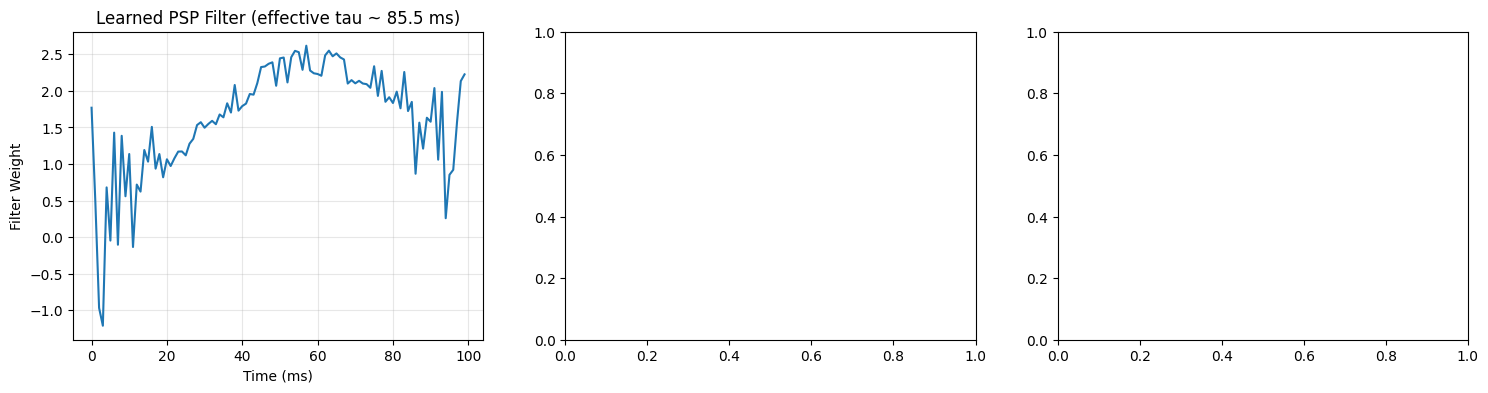

In [16]:
print("=== Learned Parameter Analysis (CCISI, learnable tau + delay) ===")

# Effective tau estimated from PSP filter peak
tau_val = net.get_tau().item() / MS
print(f"Learned effective tau: {tau_val:.2f} ms")

# PSP filter weight statistics
filter_weights = net.psp_filter.weight.data.squeeze().cpu().numpy()
print(
    f"PSP filter — max: {np.max(np.abs(filter_weights)):.4f}, "
    f"mean: {np.mean(filter_weights):.4f}, "
    f"length: {len(filter_weights)} taps"
)

# Delay statistics
delays = net.get_delays()
for delay_name, delay_values in delays.items():
    if len(delay_values) > 0:
        print(
            f"Learned {delay_name}: "
            f"mean={np.mean(delay_values):.2f}, "
            f"std={np.std(delay_values):.2f}, "
            f"min={np.min(delay_values):.2f}, "
            f"max={np.max(delay_values):.2f}"
        )

# Plot the learned PSP filter and delay distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# PSP filter (unflipped to show actual temporal response)
filter_display = np.flip(filter_weights)
axes[0].plot(filter_display)
axes[0].set_xlabel("Time (ms)")
axes[0].set_ylabel("Filter Weight")
axes[0].set_title(f"Learned PSP Filter (effective tau ~ {tau_val:.1f} ms)")
axes[0].grid(True, alpha=0.3)

# Delay1 histogram
if "delay1" in delays and len(delays["delay1"]) > 0:
    axes[1].hist(delays["delay1"], bins=20, color="tab:blue", alpha=0.7, edgecolor="black")
    axes[1].set_xlabel("Delay (time steps)")
    axes[1].set_ylabel("Count")
    axes[1].set_title(f"Delay1 Distribution (input layer, n={len(delays['delay1'])})")
    axes[1].grid(True, alpha=0.3)

# Delay2 histogram
if "delay2" in delays and len(delays["delay2"]) > 0:
    axes[2].hist(delays["delay2"], bins=20, color="tab:orange", alpha=0.7, edgecolor="black")
    axes[2].set_xlabel("Delay (time steps)")
    axes[2].set_ylabel("Count")
    axes[2].set_title(f"Delay2 Distribution (hidden layer, n={len(delays['delay2'])})")
    axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Weight statistics per layer
print("\nWeight statistics:")
for name, param in net.named_parameters():
    if "weight" in name:
        w = param.data
        print(
            f"  {name}: mean={w.mean().item():.4f}, std={w.std().item():.4f}, "
            f"shape={list(w.shape)}"
        )

## 16. Summary and Interpretation

Print a concise summary of the experiment results and interpret the
accuracy-vs-f curve in the context of the CCISI temporal coding question.

In [ ]:
print("=" * 62)
print("EXPERIMENT 1B SUMMARY: CCISI Hidden-Layer Perturbation")
print("Model: SGD-delay with learnable tau + learnable delays")
print("=" * 62)
print(f"{'f':>6}  {'Accuracy':>10}  {'Std':>8}")
print("-" * 30)
for f_val in sorted(sweep_results.keys()):
    data = sweep_results[f_val]
    print(f"{f_val:>6.1f}  {data['mean']:>10.4f}  {data['std']:>8.4f}")

# Accuracy drop from clean to fully-random hidden representation
acc_f0 = sweep_results[0.0]["mean"]
acc_f1 = sweep_results[1.0]["mean"]
drop   = acc_f0 - acc_f1
print(f"\nAccuracy drop (f=0 to f=1): {drop:.4f}")

if drop > 0.05:
    print("-> The hidden layer PRESERVES temporal structure.")
    print("   Cross-channel ISI information is maintained as a timing code.")
else:
    print("-> The hidden layer COLLAPSES temporal structure.")
    print("   Cross-channel ISI information has been converted to a rate code.")

# Delay summary
delays = net.get_delays()
for delay_name, delay_values in delays.items():
    if len(delay_values) > 0:
        print(f"\n{delay_name}: mean={np.mean(delay_values):.2f}, std={np.std(delay_values):.2f}")

print(f"\nOutput files in: log/")
print("Next step: compare with ccisi_tau.ipynb results (SGD tau-only model).")

EXPERIMENT 1B SUMMARY: CCISI Hidden-Layer Perturbation
Model: SGD-delay with learnable tau + learnable delays
     f    Accuracy       Std
------------------------------
   0.0      0.9519    0.0000
   0.1      0.9488    0.0017
   0.2      0.9549    0.0046
   0.3      0.9444    0.0045
   0.4      0.9420    0.0071
   0.5      0.9315    0.0055
   0.6      0.8926    0.0026
   0.7      0.8525    0.0023
   0.8      0.8272    0.0057
   0.9      0.8031    0.0113
   1.0      0.7920    0.0031

Accuracy drop (f=0 to f=1): 0.1599
-> The hidden layer PRESERVES temporal structure.
   Cross-channel ISI information is maintained as a timing code.

delay1: mean=10.01, std=6.09

delay2: mean=23.06, std=16.41

Output files in: log/
Next step: compare with ccisi_tau.ipynb results (SGD tau-only model).
